In [121]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi

import skimage.io as io
import skimage.draw as draw
import skimage.exposure as exp
import skimage.color as color
import skimage.filters as filters
import skimage.morphology as morph
import skimage.measure as measure
import skimage.util as util
import tifffile

import scipy.signal as sig
from copy import deepcopy as cp

import os, csv
import glob
import pandas as pd
import json

In [2]:
px_per_100um = 575.731
micron_per_pixel = px_per_100um / 100

In [3]:
def get_ratios(
    img,
    position=(0,0),
    size=100,
    show=False,
):
    img_ = cp(img)
    
    y1, x1 = position[0], position[1]
    y2, x2 = y1 + size, x1 + size

    crop_img = img_[y1:y2, x1:x2]
    
    ratios = []
    for i in range(3):
        ch = crop_img[...,i]
        mean = np.mean(ch)
        ratio = mean / 1
        ratios.append(ratio)
    
    if show:
        fig, ax = plt.subplots(1,2, figsize=(12,10))
        fig.suptitle("Color correction region")
        
        draw_img = img_.copy()
        
        rr, cc = draw.rectangle(
        (y1, x1), (y2, x2), shape=img.shape
        )
        
        draw_img[rr, cc] = [0,0,1]
            
        ax[0].imshow(draw_img)
        ax[0].axis('off')
        
        ax[1].imshow(crop_img)
        
        plt.tight_layout()
        plt.show()
        plt.close()
    
    return ratios

In [4]:
def color_correct(
    img,
    ratios=(1,1,1),
):  
    corr_chs = [
        img[...,i] / ratios[i]
        for i in range(3)
    ]
    
    corr_img = np.stack(corr_chs, axis=-1)
    corr_img = np.clip(corr_img, 0, 1)
    
    return corr_img

In [5]:
def prep(
    img,
    sigma=3,
):             
    adj_chs = []
    
    for i in range(3):
        ch = img[...,i]
        norm_ch = ndi.gaussian_filter(ch, sigma)
        adj_chs.append(norm_ch)
        
    prep_img = np.stack(adj_chs, axis=-1)
    prep_img = np.clip(prep_img, 0, 1)

    return prep_img

In [6]:
def prep_pol(
    img,
    sigma=2,
    radius=10,
):  
    hsv_img = color.rgb2hsv(img)
    value_ch = hsv_img[...,2]
    value_ch_b = ndi.gaussian_filter(value_ch, sigma=sigma)
    
    value_ch_open = morph.opening(value_ch_b, footprint=morph.disk(radius))
    value_ch_recon = morph.reconstruction(value_ch_open, value_ch_b)
    value_ch_recon = value_ch_b - value_ch_recon
    
    value_ch_corr = exp.equalize_adapthist(value_ch_recon)
    
    hsv_prep_img = cp(hsv_img)
    hsv_prep_img[..., 2] = value_ch_corr

    return hsv_prep_img

In [7]:
def thresh_pol(
    hsv_img,
    opening_radius=3,
    min_sat=0.05,
    max_obj_area=60000,
):   
    hsv_img_c = prep_pol(hsv_img)
    
    hue = hsv_img_c[..., 0]
    sat = hsv_img_c[..., 1]
    val = hsv_img_c[..., 2]
    
    thresh = filters.threshold_otsu(val)
    mask = val >= thresh
    mask = mask & (sat >= min_sat)
    mask = morph.remove_small_objects(mask, max_size=60)
    
    labelled = measure.label(mask, connectivity=2)
    props = measure.regionprops(labelled)
    keep = np.zeros_like(mask, dtype=bool)
    for prop in props:
        if prop.area <= max_obj_area:
            keep[labelled == prop.label] = True
    mask = keep
    mask_ero = ndi.binary_erosion(mask, structure=morph.disk(1))
    mask = ndi.binary_opening(mask_ero, structure=morph.disk(opening_radius))
    
    return hue, mask

In [ ]:
def entropy_mask(
    img,
    entropy_radius=3,
    close_radius=1,
    show=False,
):
    img_ = cp(img)
    
    img_c = prep(img_)

    hsv = color.rgb2hsv(img_c)

    val_ch_f = hsv[...,2]
    val_ch = util.img_as_ubyte(val_ch_f)
    
    val_ent = filters.rank.entropy(val_ch, morph.disk(5))

    hist = list(
        np.histogram(val_ent, 32)
    )
    min_index = list(
        sig.argrelextrema(hist[0], np.less)
    )
    n_peaks = len(
        sig.find_peaks(hist[0], prominence=0.1, distance=15)
    )
    
    for i in range(len(min_index[0])):
        temp_thresh = hist[1][min_index[0][i]]
        if temp_thresh > 1 and temp_thresh < 4:
            thresh_localminimal = temp_thresh

    ent = filters.rank.entropy(val_ch, morph.disk(entropy_radius))
    ent_filt = np.ones_like(ent, dtype='b')

    ent_filt[ent < thresh_localminimal] = False

    mask_close = ndi.binary_closing(
        ent_filt,
        structure=morph.disk(close_radius)
    )

    mask_ero = ndi.binary_erosion(
        mask_close,
        structure=morph.disk(1)
    )

    mask = ndi.binary_fill_holes(mask_ero)

    lbl = measure.label(mask, connectivity=2)
    regprops = measure.regionprops(lbl)

    area_data = []
    for i, region in enumerate(regprops):
        region_mask = ( lbl == (i + 1) )
        ent_mean = np.mean(ent[region_mask])
        area_data.append(region.area * ent_mean)
    """    
    ranked = sorted(
        range(len(area_data)),
        key=lambda i: area_data[i],
        reverse=True
    )
    
    top_indices = ranked[:n_peaks]
    
    for index in top_indices:
        max_mask = ( lbl == (index + 1) )
    """
    max_index = area_data.index(max(area_data))
    max_mask = ( lbl == (max_index + 1) )
    
    return val_ch_f, max_mask

In [ ]:
def hue_segment(
    img,
    entropy_mask=None,
):
    img_ = cp(img)
    
    hue, pol_mask = thresh_pol(img_)
    
    h = hue  # hue in [0, 1]

    # Literature ranges / 255 → [0, 1] scale
    red  = ((h >= 2/255) & (h <= 9/255)) | ((h >= 230/255) & (h <= 1.0))
    orange  = (h >= 10/255) & (h <= 38/255)
    yellow  = (h >= 39/255) & (h <= 51/255)
    green   = (h >= 52/255) & (h <= 128/255)
    artefact = (h >= 129/255) & (h <= 229/255)
    combined = red | orange | yellow | green

    res_keys = [
        'Red',
        'Orange',
        'Yellow',
        'Green',
        'Combined',
        'Tissue'
    ]

    results = {
        key: {
        'Mask' : None,
        'Labels': None,
        'Properties': None
        }
        for key in res_keys
    }

    tissue_mask = pol_mask & (entropy_mask > 0)

    tissue_bool = tissue_mask > 0

    for area, key in zip(
        [ red, orange, yellow, green, combined, entropy_mask ],
        res_keys
        ): 
            if key == 'Tissue':
                mask = entropy_mask
            else:
                mask = area & tissue_bool
                
            lbl = measure.label(
                mask,
                connectivity=2
            )

            props = measure.regionprops_table(
                lbl,
                
            )

            results[key]['Mask'] = mask
            results[key]['Labels'] = lbl
            results[key]['Properties'] = props
    
    return results

In [10]:
def get_groups(
    base_dir,
    group_names,
    dir_before=False,
    dir_after=False,
):
    groups = {}

    for group_name in group_names:
        pattern = os.path.join(base_dir, group_name, '*.tif')
        
        if dir_before:
            pattern = os.path.join(base_dir, '*', group_name, '*.tif')
        if dir_after:
            pattern = os.path.join(base_dir, group_name, '*', '*.tif')
        if dir_before and dir_after:
            pattern = os.path.join(base_dir, '*', group_name, '*', '*.tif')
            
        print(pattern)
        matches = sorted(glob.glob(pattern))
        groups[group_name] = matches
        print("%s: %d stack(s) found" % (group_name, len(matches)))
        for m in matches:
            print("    %s" % m)
        
    return groups

In [13]:
base_dir = '/home/vpc/Projects/Picro_Lu'
group_names = [ 'Capsule', 'Stroma']

groups = get_groups(base_dir, group_names, dir_after=True)

/home/vpc/Projects/Picro_Lu/Capsule/*/*.tif
Capsule: 4 stack(s) found
    /home/vpc/Projects/Picro_Lu/Capsule/21d-1/21d-1_MMStack_Pos0.ome.tif
    /home/vpc/Projects/Picro_Lu/Capsule/21d-2/21d-2_MMStack_Pos0.ome.tif
    /home/vpc/Projects/Picro_Lu/Capsule/21d-3/21d-3_MMStack_Pos0.ome.tif
    /home/vpc/Projects/Picro_Lu/Capsule/21d-4/21d-4_MMStack_Pos0.ome.tif
/home/vpc/Projects/Picro_Lu/Stroma/*/*.tif
Stroma: 5 stack(s) found
    /home/vpc/Projects/Picro_Lu/Stroma/21d-1/21d-1_MMStack_Pos0.ome.tif
    /home/vpc/Projects/Picro_Lu/Stroma/21d-2/21d-2_MMStack_Pos0.ome.tif
    /home/vpc/Projects/Picro_Lu/Stroma/21d-3/21d-3_MMStack_Pos0.ome.tif
    /home/vpc/Projects/Picro_Lu/Stroma/21d-4/21d-4_MMStack_Pos0.ome.tif
    /home/vpc/Projects/Picro_Lu/Stroma/21d-5/21d-5_MMStack_Pos0.ome.tif


OME series: incompatible page shape (1920, 2560, 3); expected (1, 1920, 2560)


Capsule 4


OME series: incompatible page shape (1920, 2560, 3); expected (1, 1920, 2560)
OME series: incompatible page shape (1920, 2560, 3); expected (1, 1920, 2560)
OME series: incompatible page shape (1920, 2560, 3); expected (1, 1920, 2560)
OME series: incompatible page shape (1920, 2560, 3); expected (1, 1920, 2560)


Stroma 5


OME series: incompatible page shape (1920, 2560, 3); expected (1, 1920, 2560)
OME series: incompatible page shape (1920, 2560, 3); expected (1, 1920, 2560)
OME series: incompatible page shape (1920, 2560, 3); expected (1, 1920, 2560)
OME series: incompatible page shape (1920, 2560, 3); expected (1, 1920, 2560)


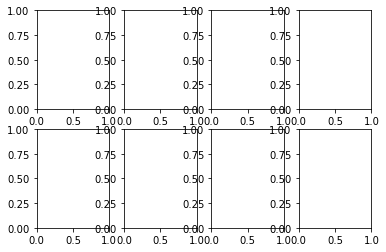

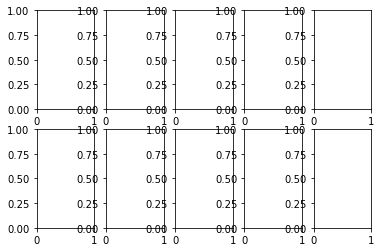

In [ ]:
for group_name, paths in groups.items():
    num_imgs = len(paths)
    print(group_name, num_imgs)
    
    img_list = []
    for path in paths:
        all_imgs_ub = io.imread(path, plugin='tifffile')
        all_imgs = img_as_float32(all_imgs_ub)
        nonpol_dupl, pol_dupl = all_imgs[0:2], all_imgs[2:4]
        nonpol, pol = [
            ( dupl[0] + dupl[1] ) / 2.0
            for dupl in [ nonpol_dupl, pol_dupl ]
        ]
        img_list.append(nonpol)
        img_list.append(pol)
        
    img_stack = np.stack(img_list)
    stack_len = len(img_stack)

    fig, ax = plt.subplots(2, num_imgs)
    nonpol_ax = ax[0]
    pol_ax = ax[1]
    
    stack_path = os.path.join(
        'Esponja', group_name
    )
    os.makedirs(stack_path, exist_ok=True)
    stack_fn = os.path.join(
        stack_path, 'stack0.tif'
    )
    io.imsave(stack_fn, img_stack, plugin='tifffile')

In [101]:
base_dir = '/home/vpc/Pictures/example_images/Esponja/'
group_names = ['Capsule', 'Stroma']
groups = get_groups(base_dir, group_names)

/home/vpc/Pictures/example_images/Esponja/Capsule/*.tif
Capsule: 1 stack(s) found
    /home/vpc/Pictures/example_images/Esponja/Capsule/stack0.tif
/home/vpc/Pictures/example_images/Esponja/Stroma/*.tif
Stroma: 1 stack(s) found
    /home/vpc/Pictures/example_images/Esponja/Stroma/stack0.tif


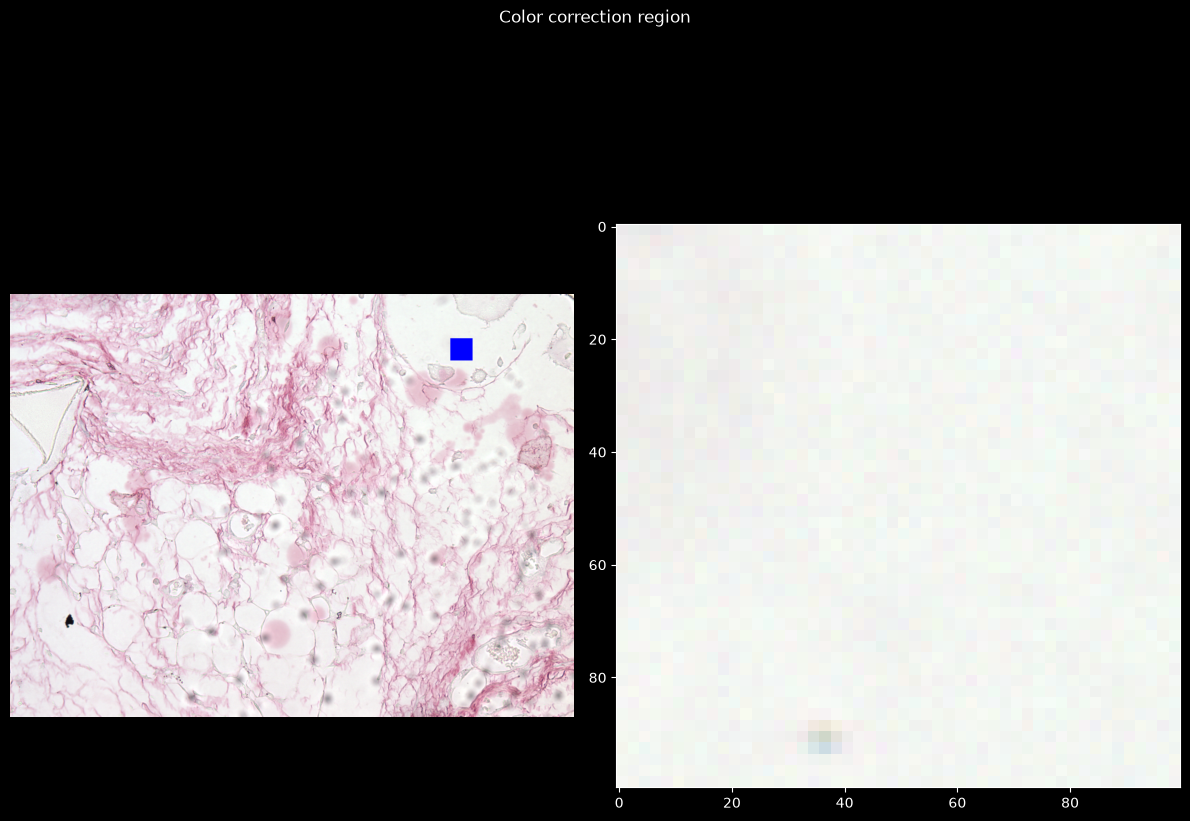

In [12]:
cal_img_stack = groups['Stroma'][0]
cal_stack = tifffile.imread(cal_img_stack)
cal_img = cal_stack[2]
cal_img_pol = cal_stack[3]

cal_ratios = get_ratios(
    cal_img,
    position=(200, 2000),
    size=100,
    show=True
)

In [123]:
def process_stack(
    filepath,
    output_path,
    cal_ratios,
):
    basename = os.path.basename(filepath).replace(".tif", "")
    
    image_stack = tifffile.imread(filepath)
    print(f"Reading {basename}")

    n_imgs = len(image_stack)

    shape = image_stack.shape
    img_h, img_w = shape[1:3]

    stack_results = []

    for i in range(0, n_imgs, 2):
        
        img_ix = i // 2

        print(f"Processing image number {img_ix + 1} of {n_imgs // 2}")
        
        nonpol_img, pol_img = [
            color_correct(
                image_stack[j],
                ratios=cal_ratios
            )
            for j in [i, i + 1]
        ]

        intensity, nonpol_lbl, nonpol_mask = entropy_mask(nonpol_img)

        results = hue_segment(
            pol_img,
            entropy_mask=nonpol_mask
        )
        
        stack_results.append(results)
        
    return stack_results


In [ ]:

    # --- Hue fractions within collagen ---
    hue_fractions = {}
    hue_px_counts = {}
    col_masks = []
    hue_overlays = []

    for i in range(n_stacks):
        _, hue_masks, hue_overlay = hue_segment(
            pol_images[i],
            pol_mask=pol_masks[i],
            entropy_mask=entropy_masks[i]
        )
        
    
        total_collagen = hue_masks['combined']
        for color in hue_masks.keys():
            if total_collagen > 0:
                px_count = np.sum(hue_masks[color])
                pct = px_count / total_collagen
            else:
                px_count = 0
                pct = 0
            hue_px_counts[name].append(px_count)
            hue_fractions[name].append(pct)
            
        hue_overlays.append(hue_overlay)
        col_masks.append(total_collagen)

    # --- Results ---
    tissue_px_counts = [np.sum(m > 0) for m in entropy_masks]
    tissue_area_fractions = [c / (img_h * img_w) for c in tissue_px_counts]
        
    # --- Collagen percentage and pixel counts ---
    collagen_pct = []
    collagen_px_counts = []
    for i in range(n_stacks):
        overlap = np.sum((col_masks[i] > 0) & (entropy_masks[i] > 0))
        tissue_px = tissue_px_counts[i]
        collagen_pct.append(overlap / tissue_px if tissue_px > 0 else 0)
        collagen_px_counts.append(int(overlap))
    

    
    # --- Summary stats ---
    result = {
        'basename': basename,
        'n_stacks': n_stacks,
        'img_shape': (img_h, img_w),
        'tissue_areas': tissue_areas,
        'tissue_px_counts': tissue_px_counts,
        'collagen_pct': collagen_pct,
        'collagen_px_counts': collagen_px_counts,
        'hue_fractions': hue_fractions,
        'tissue_area_mean': float(np.mean(tissue_areas)),
        'tissue_area_std': float(np.std(tissue_areas)),
        'collagen_pct_mean': float(np.mean(collagen_pct)),
        'collagen_pct_std': float(np.std(collagen_pct)),
    }
    
    for name in class_order:
        result[name + '_mean'] = float(np.mean(hue_fractions[name]))
        result[name + '_std'] = float(np.std(hue_fractions[name]))

    if output_images:
        output_imgs_path = os.path.join(
            output_path,
            basename)
        
        os.makedirs(output_imgs_path, exist_ok=True)
                
        for process_step_dirname, image_list in zip([ 
            "Brightfield corrected", "Polarized corrected",
            "Tissue area masks", "Polarized collagen masks",
            "Hue masks"
            ], [
            bfd_images, pol_images, entropy_masks,
            pol_masks, hue_masks
            ]
        ):
            output_step_path = os.path.join(
                output_imgs_path,
                process_step_dirname)

            os.makedirs(output_step_path, exist_ok=True)
            
            for i, img in enumerate(image_list):
                out_filename = os.path.join(
                    output_step_path,
                    f"{i}.tif")
                
                img_to_save_ubyte = img_as_ubyte(img)
                print(f"Saving {process_step_dirname} image number {i} to {out_filename}")
                
                io.imsave(
                    out_filename,
                    img_to_save_ubyte
                )
                
    return result

In [ ]:
# ═══════════════════════════════════════════════════════════
# GROUP COMPARISON
# ═══════════════════════════════════════════════════════════

output_dir = 'Picro Sirius Analysis Images'
os.makedirs(output_dir, exist_ok=True)

# Process all stacks
group_results = {}

pixel_area_um2 = micron_per_pixel ** 2

In [124]:
for group_name, paths in groups.items():
    group_results[group_name] = {}

    for fp in paths:
        print("\n  Processing: %s" % fp)
        output_group_dir = os.path.join(
            output_dir,
            group_name)
        
        os.makedirs(output_group_dir, exist_ok=True)
        
        gp_result = process_stack(
            fp,
            output_group_dir,
            cal_ratios,
        )

        group_results[group_name] = gp_result



  Processing: /home/vpc/Pictures/example_images/Esponja/Capsule/stack0.tif
Reading stack0
Processing image number 1 of 4
Processing image number 2 of 4
Processing image number 3 of 4
Processing image number 4 of 4

  Processing: /home/vpc/Pictures/example_images/Esponja/Stroma/stack0.tif
Reading stack0
Processing image number 1 of 5
Processing image number 2 of 5
Processing image number 3 of 5
Processing image number 4 of 5
Processing image number 5 of 5


In [164]:
areas = np.sum(
    [ group_results['Capsule'][0]['Orange']['Properties'][i].area_filled
    for i in range(len(group_results['Capsule'][0]['Orange']['Properties'])) ]
)

print(areas)
print(np.sum(group_results['Capsule'][0]['Orange']['Mask']))

47882.0
47314


Capsule


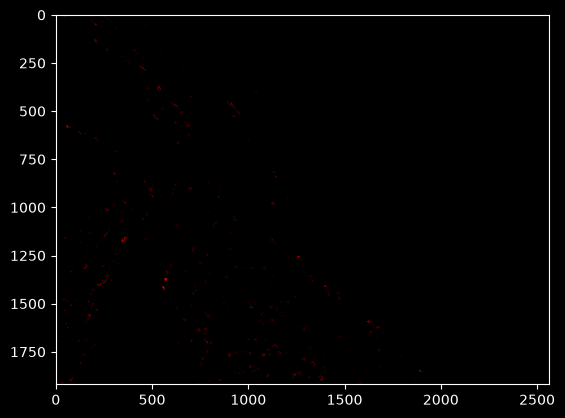

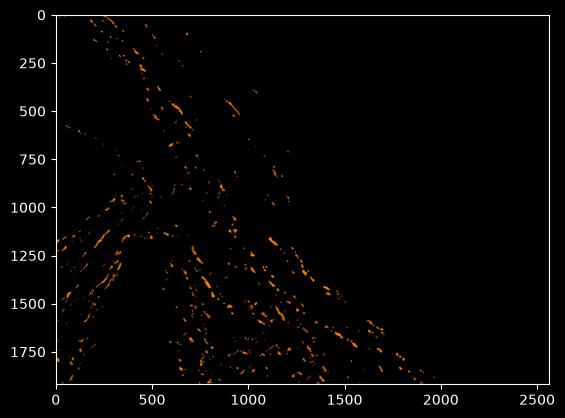

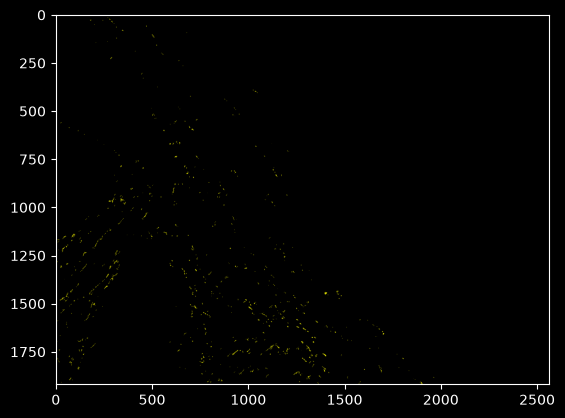

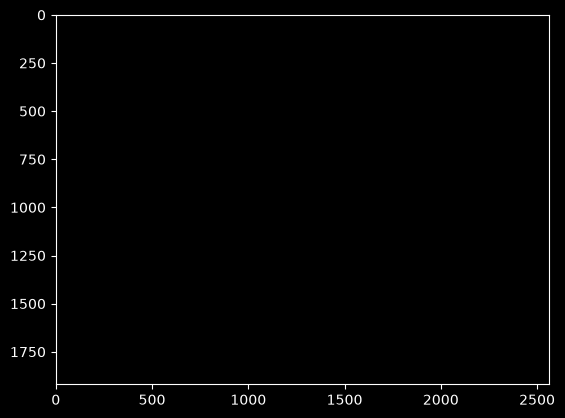

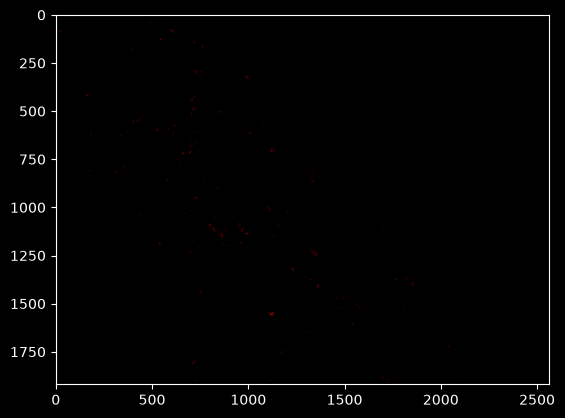

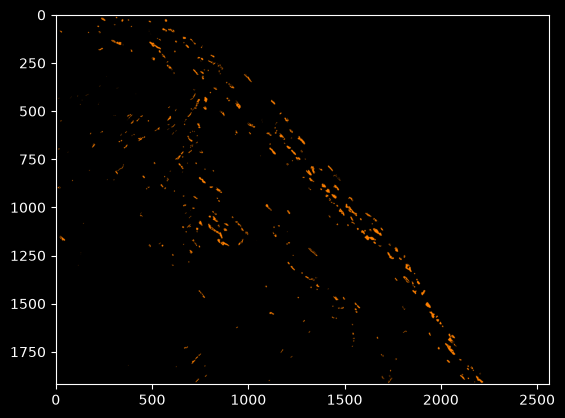

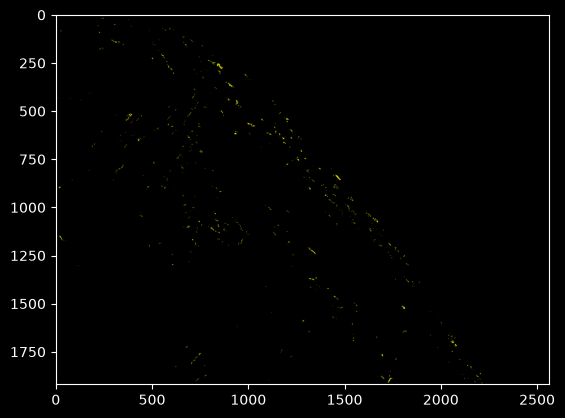

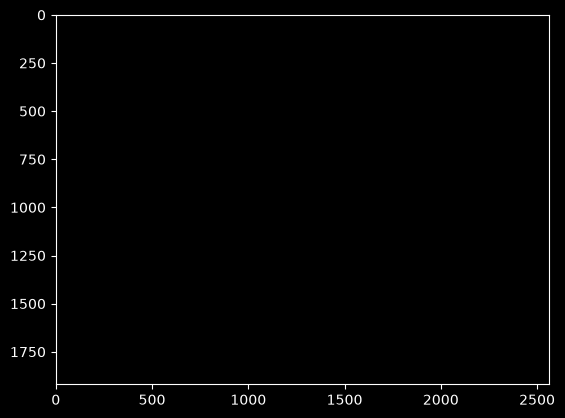

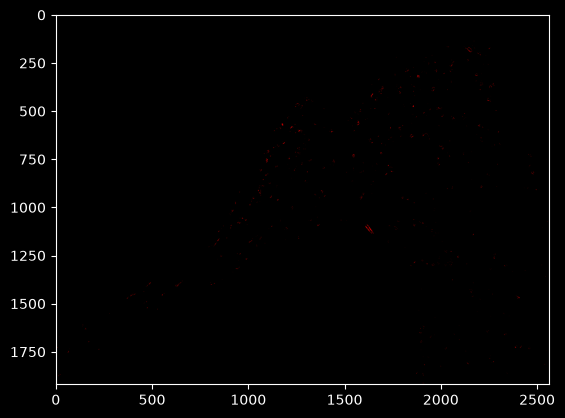

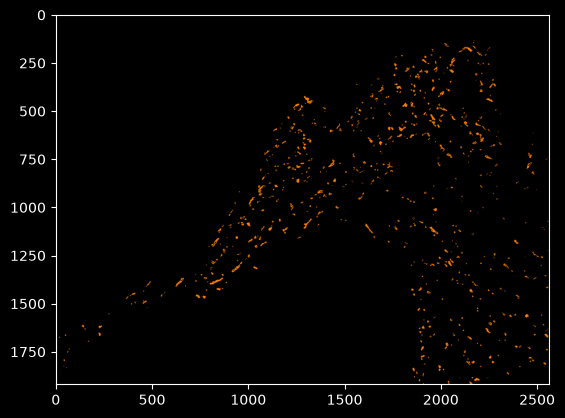

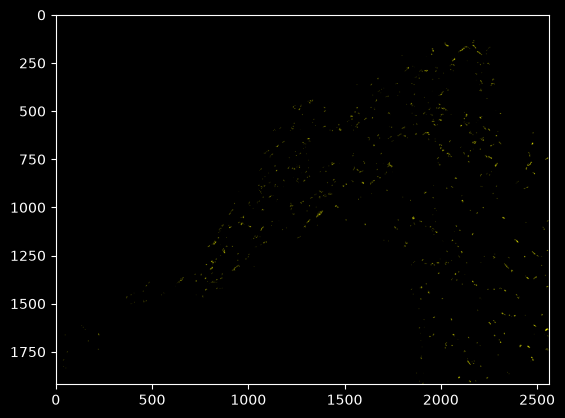

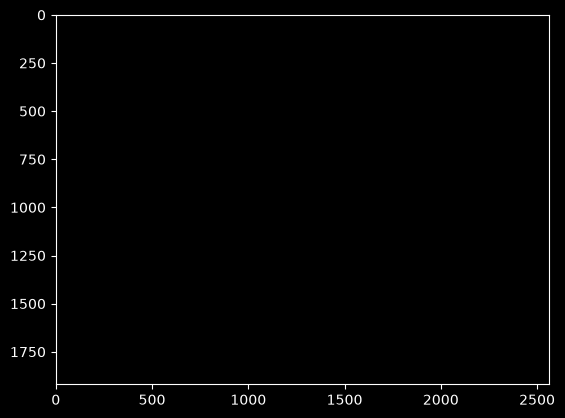

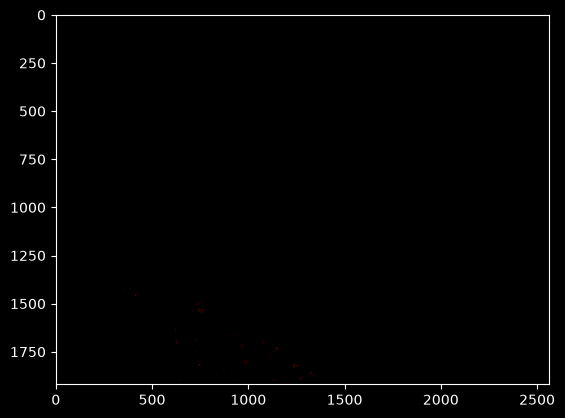

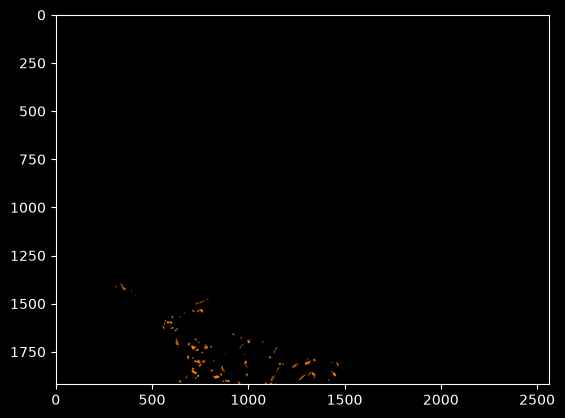

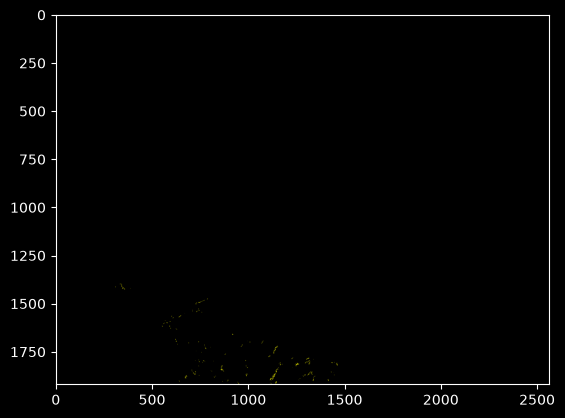

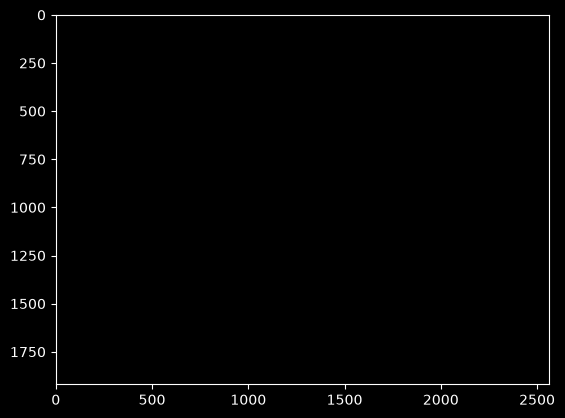

Stroma


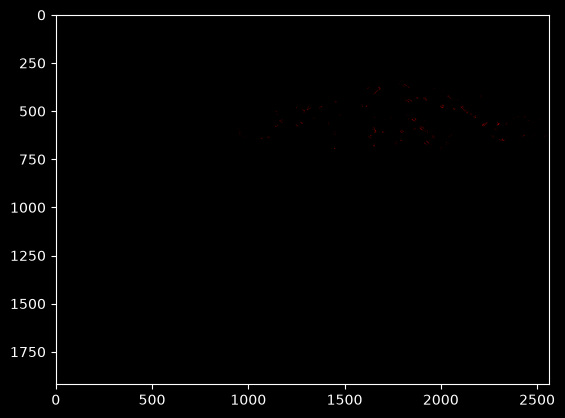

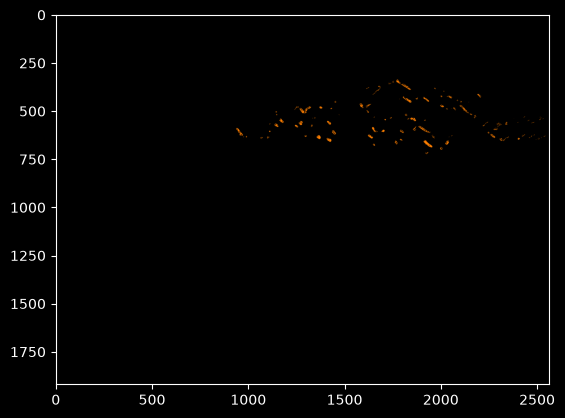

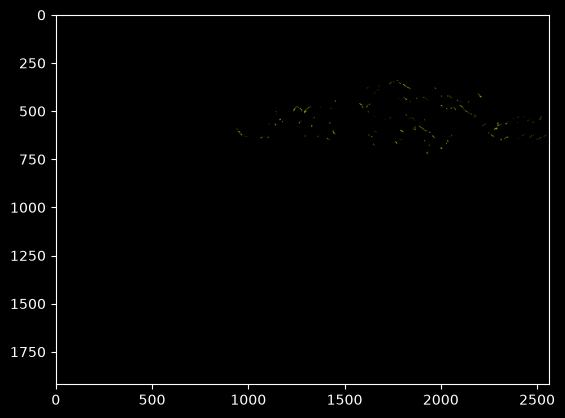

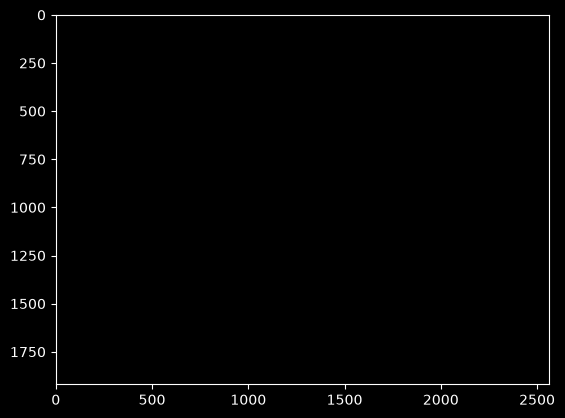

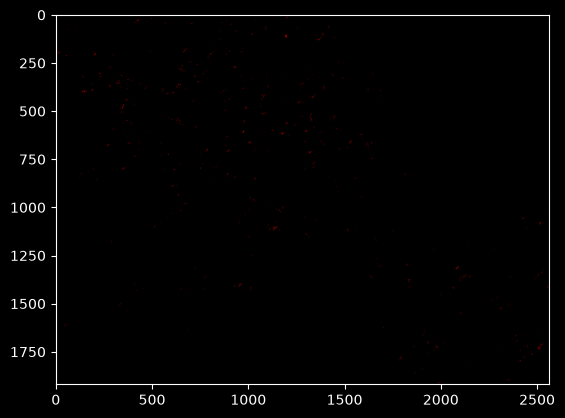

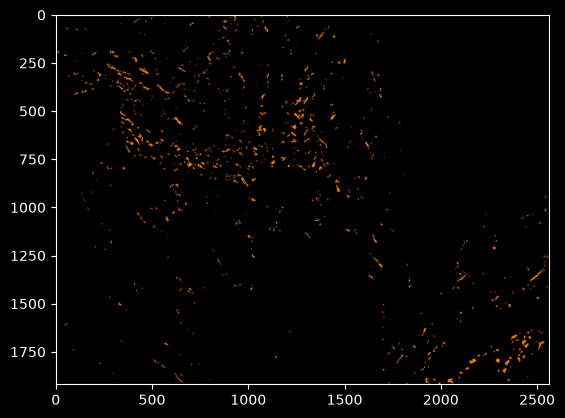

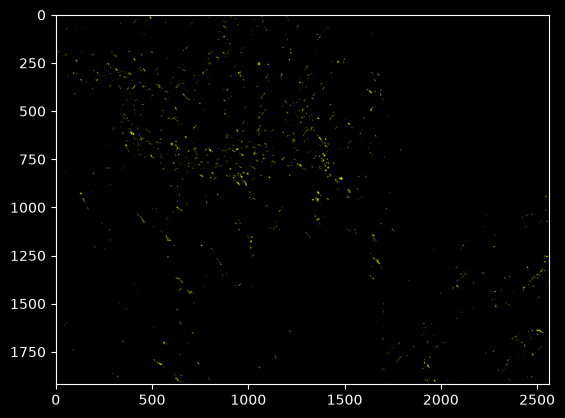

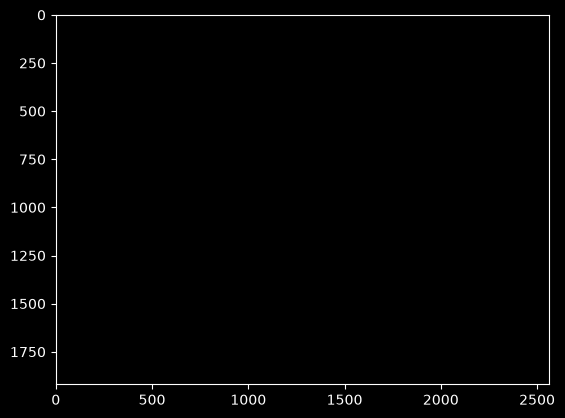

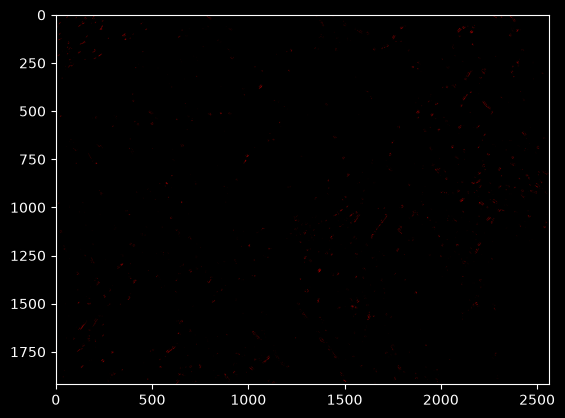

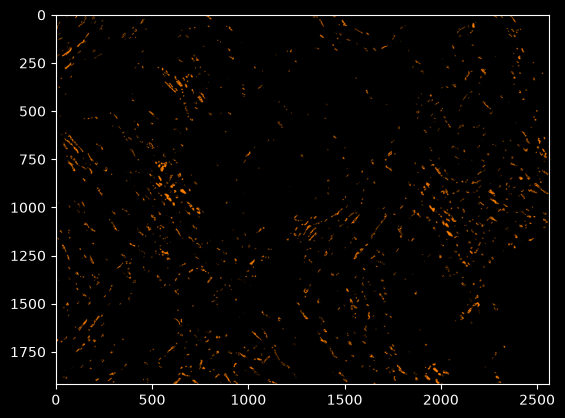

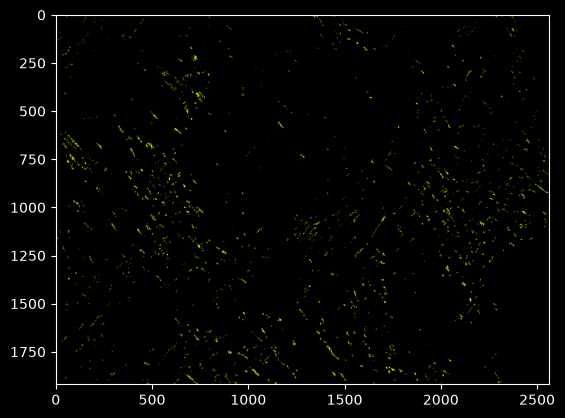

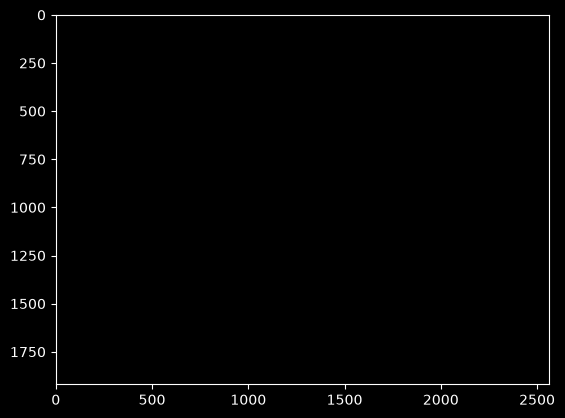

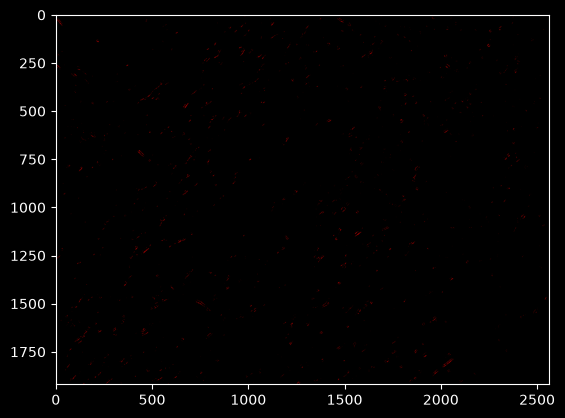

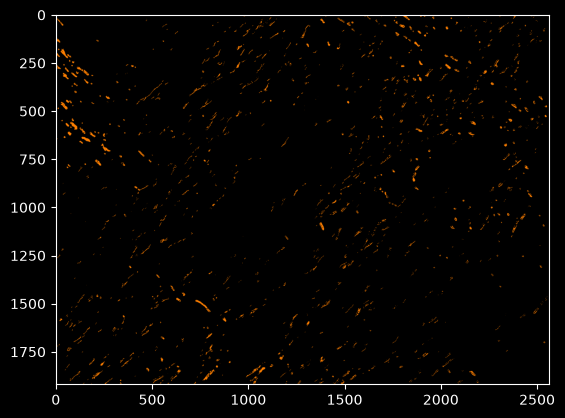

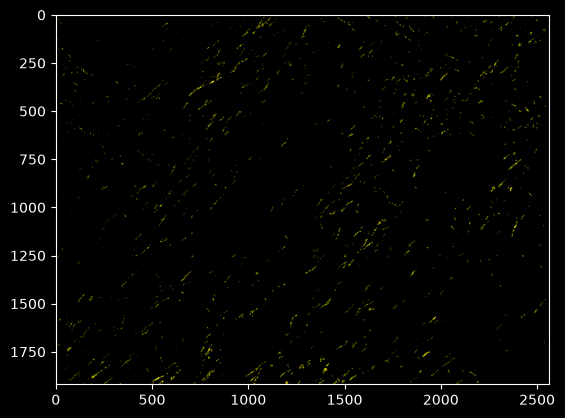

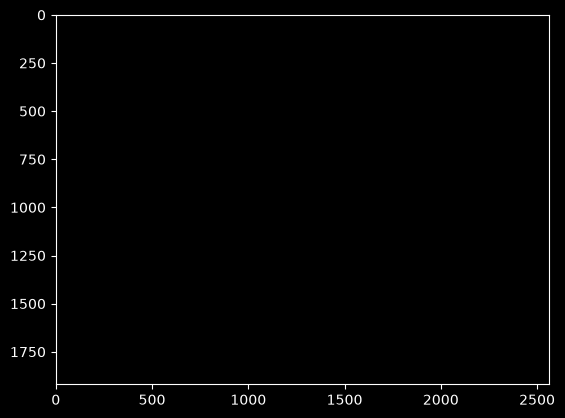

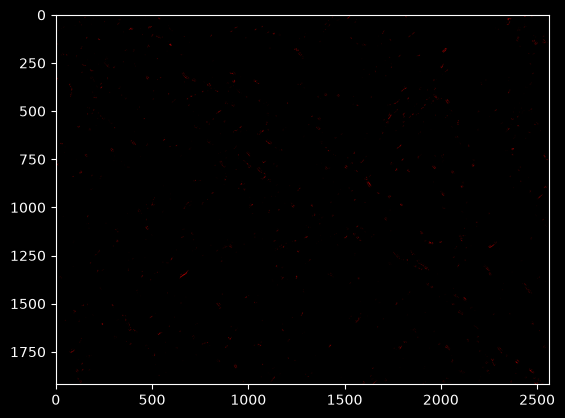

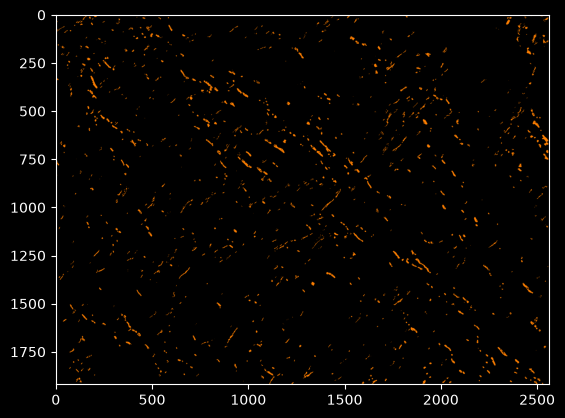

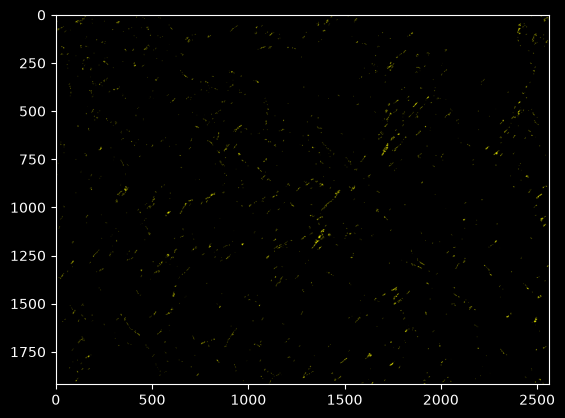

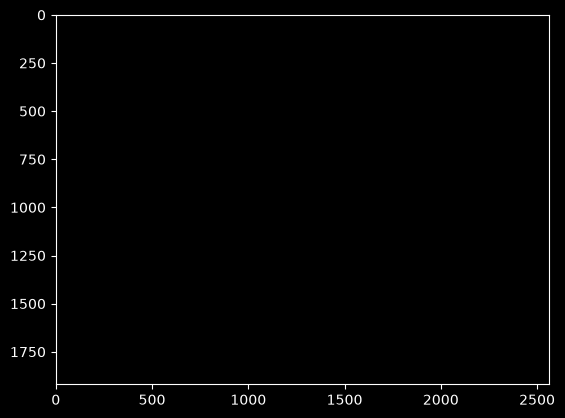

In [ ]:
for group_name, color in group_results.items():
    print(group_name)
    
    for results in color:
        masks = []
        for area in results:
            mask = results[area]['Mask']

        



            
        plt.imshow(overlay)
        plt.show()
        plt.close()

In [ ]:


        
        group_results[group_name].append(res)
        all_group_pct[group_name].extend(res['collagen_pct'])
        area_um2 = np.array(res['collagen_px_counts']) * pixel_area_um2
        all_group_area[group_name].extend(area_um2.tolist())
        for name in class_order:
            all_group_hues[group_name][name].extend(res['hue_fractions'][name])

In [87]:
print("\n─── Group summary ───")
for gn in group_names:
    pct = np.array(all_group_pct[gn])
    area = np.array(all_group_area[gn])
    print("%s: %d fields total" % (gn, len(pct)))
    print("  Collagen:    %.2f%% ± %.2f%%" % (pct.mean(), pct.std()))
    print("  Area:        %.2f k·µm² ± %.2f k·µm²" % (area.mean()/1000, area.std()/1000))
    for name in class_order:
        h = np.array(all_group_hues[gn][name])
        print("  %-10s: %.1f%% ± %.1f%%" % (name, h.mean(), h.std()))


─── Group summary ───
Capsule: 4 fields total
  Collagen:    4.61% ± 2.21%
  Area:        2021.62 k·µm² ± 829.59 k·µm²
  red       : 6.1% ± 1.7%
  orange    : 60.5% ± 4.5%
  yellow    : 12.2% ± 0.3%
  green     : 11.3% ± 4.7%
Stroma: 5 fields total
  Collagen:    4.45% ± 1.89%
  Area:        4223.26 k·µm² ± 2045.88 k·µm²
  red       : 6.6% ± 1.7%
  orange    : 49.5% ± 7.7%
  yellow    : 17.2% ± 4.2%
  green     : 18.3% ± 7.1%


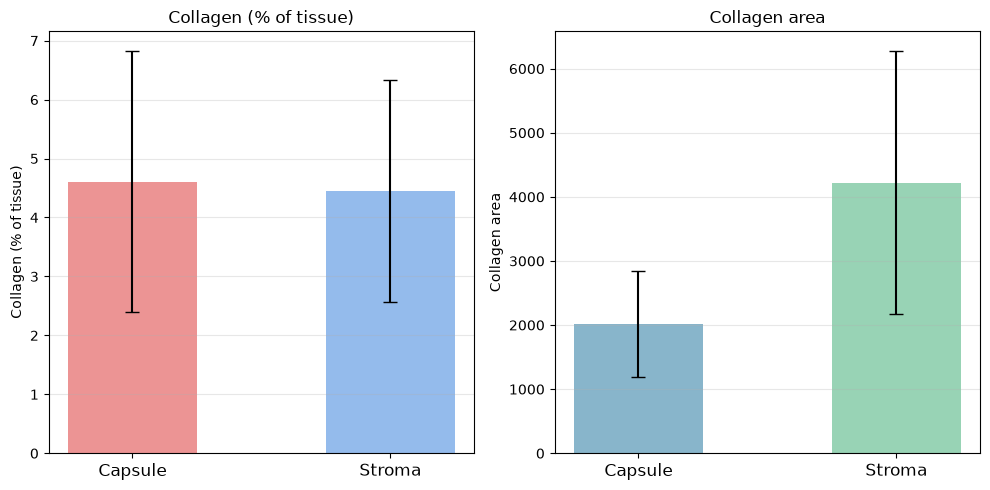

In [88]:
# ── Group comparison: collagen % and area ──
colours = ['#E87A7A', '#7AAAE8']  # red-ish, blue-ish
x = np.arange(len(group_names))
bar_w = 0.5

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for mi, (metric, label, unit, colour) in enumerate([
    ('pct', 'Collagen (% of tissue)', '%', '#4682B4'),
    ('area', 'Collagen area', 'k·µm²', '#3CB371'),
]):
    ax = axes[mi]
    means = []
    errs  = []
    for gn in group_names:
        data = np.array(all_group_pct[gn] if metric == 'pct' else all_group_area[gn])
        if metric == 'area':
            data = data / 1000
        means.append(data.mean())
        errs.append(data.std())
    
    ax.bar(x, means, bar_w, yerr=errs, capsize=5,
           color=[colours[i] if metric == 'pct' else ['#6BA3BE', '#7EC8A3'][i]
                  for i in range(2)],
           alpha=0.8, error_kw=dict(ecolor='black', lw=1.5))
    ax.set_xticks(x)
    ax.set_xticklabels(group_names, fontsize=12)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'group_comparison_collagen.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

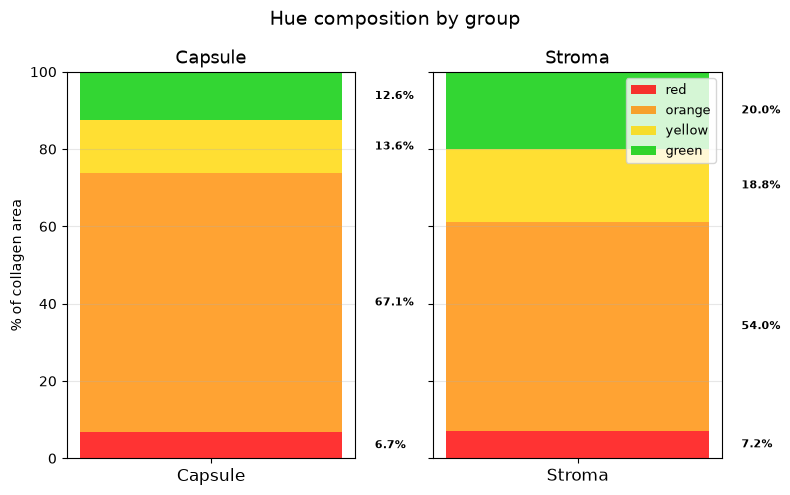

Saved: group_comparison_collagen.png, group_comparison_hue.png


In [115]:
# ── Group comparison: hue stacked bars side by side ──
class_colours = ['#FF0000', '#FF8C00', '#FFD700', '#00CC00']

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

for ai, (gn, colour) in enumerate(zip(group_names, colours)):
    ax = axes[ai]
    #means = [np.mean(all_group_hues[gn][name]) for name in class_order]
    
    means_ = []
    for color in all_group_hues[gn]:
        clist = all_group_hues[gn][color]
        mean = np.mean(clist)
        means_.append(mean)
    
    col_pct = np.sum(means_)
    q = col_pct / 100
    means = np.divide(means_, q)

    bottom = 0
    for i, (name, cc) in enumerate(zip(class_order, class_colours)):
        ax.bar(0, means[i], 0.4, bottom=bottom,
               color=cc, alpha=0.8,
               label=name if ai == 1 else None)
        ax.text(0.25, bottom + means[i]/2,
                '%.1f%%' % means[i], va='center', fontsize=8, fontweight='bold')
        bottom += means[i]
    
    ax.set_xticks([0])
    ax.set_xticklabels([gn], fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_title(gn, fontsize=13)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('% of collagen area')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Hue composition by group', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'group_comparison_hue.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("Saved: group_comparison_collagen.png, group_comparison_hue.png")

In [116]:
# ── Export group data to JSON for downstream statistics ──
import json

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

# Convert per-file results
results_export = {}
for gn in group_names:
    results_export[gn] = []
    for res in group_results[gn]:
        r = dict(res)
        for k in ['tissue_areas', 'tissue_px_counts', 'collagen_pct', 'collagen_px_counts']:
            if k in r:
                r[k] = [float(v) for v in r[k]]
        if 'hue_fractions' in r:
            r['hue_fractions'] = {h: [float(v) for v in vals]
                                  for h, vals in r['hue_fractions'].items()}
        results_export[gn].append(r)

data = {
    'group_results': results_export,
    'all_group_pct':  {gn: [float(v) for v in all_group_pct[gn]] for gn in group_names},
    'all_group_area': {gn: [float(v) for v in all_group_area[gn]] for gn in group_names},
    'all_group_hues': {
        gn: {h: [float(v) for v in all_group_hues[gn][h]] for h in class_order}
        for gn in group_names
    },
}

json_path = os.path.join(output_dir, 'group_data.json')
with open(json_path, 'w') as f:
    json.dump(data, f, cls=NumpyEncoder, indent=2)

print("Exported: %s" % json_path)
for gn in group_names:
    print("  %s: %d files, %d fields" % (
        gn, len(results_export[gn]), len(data['all_group_pct'][gn])))

Exported: Picro Sirius Analysis Images/group_data.json
  Capsule: 1 files, 4 fields
  Stroma: 1 files, 5 fields


In [117]:
with open('Picro Sirius Analysis Images/group_data.json') as f:
    data = json.load(f)